# NASA POWER y Google Trends: comparación temporal

**Ninguna variante superó el AUC mensual de la base.** Las diferencias en casos detectados deben leerse junto con el AUC y la consistencia por período; no justifican reemplazar el ensemble actual.

Se comparan cinco ampliaciones con los parámetros fijos del ensemble 50/50. Este notebook lee la evaluación guardada; no ejecuta Optuna ni reentrena al abrirlo.

[Informe y definiciones de variables](../07_results/ablacion_nasa_google_trends.md).

In [1]:
from pathlib import Path
import json
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'scripts/climate_trends_ablation.py').exists())
OUT = ROOT / 'reports/climate_trends_v1'
protocol = json.loads((OUT / 'protocol.json').read_text())
for relative, expected in protocol['sources'].items():
    assert hashlib.sha256((ROOT / relative).read_bytes()).hexdigest() == expected
comparison = pd.read_csv(OUT / 'comparison.csv')
monthly = pd.read_csv(OUT / 'monthly_metrics.csv')
blocks = pd.read_csv(OUT / 'block_metrics.csv')
components = pd.read_csv(OUT / 'component_metrics.csv')
print('Fuentes coinciden con el protocolo. Rezago:', protocol['lag_months_assumed'], 'meses.')

Fuentes coinciden con el protocolo. Rezago: 3 meses.


## Resultados

42 variables base, mismas 4.379 observaciones en 16 meses y cuatro bloques, gap de seis meses. El AUC mensual mide discriminación dentro del mes. Los casos detectados son observaciones vendedora–mes.

In [2]:
display(comparison[['variant','n_added_columns','auc_mean','auc_monthly_mean','delta_auc_monthly_mean','tp_top10','tp_top20','ap_mean']].round(6))
display(pd.read_csv(OUT / 'coverage.csv'))

,variant,n_added_columns,auc_mean,auc_monthly_mean,delta_auc_monthly_mean,tp_top10,tp_top20,ap_mean
0,transaccional,0,0.789880,0.790383,0.000000,295,546,0.596209
1,mas_nasa,13,0.788447,0.789106,-0.001277,290,546,0.592996
2,mas_trends_catalogo,5,0.788900,0.789900,-0.000483,296,545,0.591106
3,mas_trends,20,0.790110,0.789632,-0.000751,296,549,0.596205
4,mas_trends_indices,20,0.781773,0.789183,-0.001200,296,547,0.576426
5,mas_nasa_trends,33,0.789175,0.788699,-0.001684,292,545,0.592194


,partition,rows,nasa_missing_location_or_month,nasa_missing_yearly_change,trends_missing_index,trends_missing_zexp
0,development,28311,454,2418,0,23426
1,validation,4379,42,42,0,0


## Consistencia por período

In [3]:
display(blocks.pivot(index='variant', columns='fold', values='auc').round(6))
ma = monthly.loc[monthly.top_fraction.eq(.1)].pivot(index='month', columns='variant', values='auc')
delta = ma.subtract(ma.transaccional, axis=0).drop(columns='transaccional')
display(delta.gt(0).sum().rename('Meses con AUC superior a base (de 16)'))

fold,0,1,2,3
variant,,,,
mas_nasa,0.785275,0.792948,0.780129,0.795436
mas_nasa_trends,0.789671,0.793362,0.776536,0.797129
mas_trends,0.789752,0.794783,0.777875,0.798032
mas_trends_catalogo,0.784227,0.794798,0.780867,0.795709
mas_trends_indices,0.788944,0.792934,0.749996,0.795217
transaccional,0.785349,0.794934,0.781867,0.797368


variant
mas_nasa               5
mas_nasa_trends        4
mas_trends             6
mas_trends_catalogo    6
mas_trends_indices     6
Name: Meses con AUC superior a base (de 16), dtype: int64

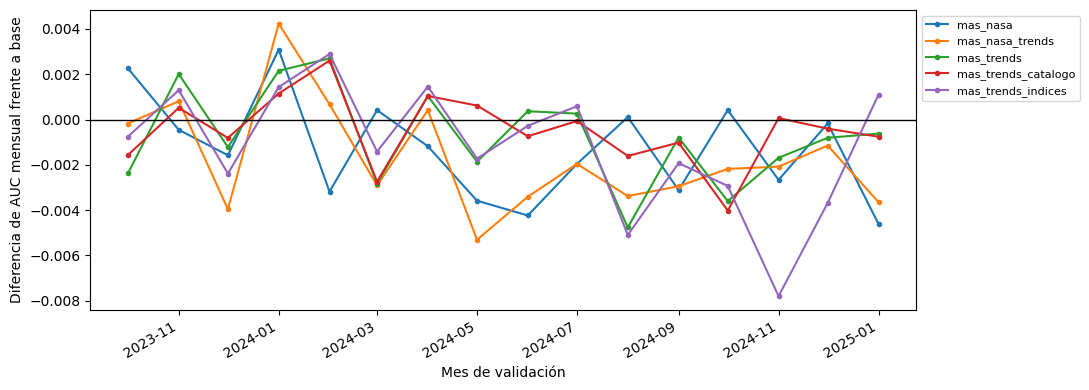

In [4]:
fig, ax = plt.subplots(figsize=(11, 4))
for name in delta:
    ax.plot(pd.to_datetime(delta.index), delta[name], marker='o', markersize=3, label=name)
ax.axhline(0, color='black', linewidth=1)
ax.set(ylabel='Diferencia de AUC mensual frente a base', xlabel='Mes de validación')
ax.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1, 1))
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## Componentes y disponibilidad de variables

In [5]:
display(components[['variant','model','auc_mean','auc_monthly_mean','tp_top10']].round(6))
display(pd.read_csv(OUT / 'feature_quality.csv').sort_values('missing_development', ascending=False).head(15))

,variant,model,auc_mean,auc_monthly_mean,tp_top10
0,transaccional,logreg,0.787625,0.787839,293
1,transaccional,xgboost,0.788335,0.789059,298
2,mas_nasa,logreg,0.785467,0.786085,281
3,mas_nasa,xgboost,0.787707,0.788612,299
4,mas_trends_catalogo,logreg,0.787266,0.788239,293
5,mas_trends_catalogo,xgboost,0.787225,0.788475,295
6,mas_trends,logreg,0.788062,0.787944,292
7,mas_trends,xgboost,0.787612,0.788177,296
8,mas_trends_indices,logreg,0.761784,0.788016,290
9,mas_trends_indices,xgboost,0.788601,0.788792,294


,variable,missing_development,distinct_development,first_month_available
36,trends_temu_zexp,23426,18,2023-08-01 00:00:00
11,nasa_precipitacion_delta12_mm,2418,4892,2017-04-01 00:00:00
10,nasa_temperatura_delta12_c,2418,5311,2017-04-01 00:00:00
20,trends_vender_por_catalogo_zexp,1620,95,2017-03-01 00:00:00
24,trends_yanbal_zexp,1620,95,2017-03-01 00:00:00
28,trends_unique_zexp,1620,95,2017-03-01 00:00:00
30,trends_esika_zexp,1620,95,2017-03-01 00:00:00
32,trends_belcorp_zexp,1620,95,2017-03-01 00:00:00
34,trends_shein_zexp,1620,95,2017-03-01 00:00:00
26,trends_natura_zexp,1620,95,2017-03-01 00:00:00


In [6]:
variables = json.loads((OUT / 'variables.json').read_text())
display(pd.DataFrame([{'variant': k, 'columnas_adicionales': len(v), 'variables': ', '.join(v)} for k,v in variables['variants'].items()]))

,variant,columnas_adicionales,variables
0,transaccional,0,
1,mas_nasa,13,"nasa_temperatura_media_c, nasa_temperatura_max..."
2,mas_trends_catalogo,5,"trends_venta_por_catalogo_zexp, trends_catalog..."
3,mas_trends,20,"trends_venta_por_catalogo_zexp, trends_catalog..."
4,mas_trends_indices,20,"trends_venta_por_catalogo_indice, trends_catal..."
5,mas_nasa_trends,33,"nasa_temperatura_media_c, nasa_temperatura_max..."


## Interpretación y límites

- La comparación principal para priorizar vendedoras es el AUC medio dentro del mes, junto con los casos detectados al mismo presupuesto mensual. El AUC de bloques de cuatro meses también compara observaciones de meses diferentes.
- NASA cambia por provincia y mes, aunque provincias que comparten celda meteorológica comparten valores. La capital provincial aproxima la ubicación; no es una medición individual ni el promedio de toda la provincia.
- Trends nacional es igual para todas las vendedoras del mes. Por sí solo no distingue a dos vendedoras de ese mes; puede afectar el nivel de probabilidades y las interacciones en árboles. Reentrenar también cambia los coeficientes de las variables transaccionales.
- **No se usó `google_trends_pe_regiones.csv` como predictor.** Tiene 25 departamentos y dos términos, pero ninguna fecha mensual. El código de extracción existente solicita el resumen de 2016-01 a 2026-02; asignarlo a años anteriores introduciría información posterior al corte. No hay series departamento × mes en este archivo.
- Las búsquedas son índices de interés relativo, no volúmenes absolutos. Cada término se descargó por separado: sus niveles no deben compararse como cantidades de búsquedas entre términos. Los índices originales están normalizados en toda la ventana de descarga.
- El z-score expansivo usa únicamente valores hasta el mes de referencia: `(valor − media histórica) / desviación estándar histórica`, con un mínimo de 12 meses. Cancela un factor multiplicativo común, pero no corrige el redondeo, muestreo ni revisiones históricas de la fuente. Si la serie es constante, queda nulo.
- Temu tiene una historia inicial de ceros: su z-score queda ausente en 23.426 de las 28.311 filas de desarrollo y recién está disponible para observaciones de agosto de 2023 (referencia mayo de 2023). La ausencia de dispersión no se presenta como una señal negativa de interés. Las columnas sin datos en un entrenamiento quedan en cero mediante el imputador; ese modelo no puede aprender su efecto.
- Para ambas fuentes se asumió un rezago de **tres meses**: por ejemplo, enero de 2025 usa octubre de 2024. No se buscó el mejor rezago. Son descargas históricas actuales, sin versiones ni fechas de publicación de cada valor: el resultado sigue siendo exploratorio y no acredita disponibilidad histórica. La provincia proviene del maestro actual.
- Imputación por mediana ajustada exclusivamente en cada entrenamiento; no se descartan observaciones con datos faltantes. No se incorporan códigos geográficos, sexo, edad, antigüedad ni los indicadores económicos del Excel a estas variantes.
- Se reutilizan validaciones ya usadas para desarrollar el modelo. No es un holdout final independiente ni una demostración de significancia estadística. Los conteos son observaciones vendedora–mes, no necesariamente personas distintas.


## Reproducir entrenamiento

Desde la raíz del repositorio: `python -m scripts.climate_trends_ablation`. Los resultados existentes se reutilizan si coinciden fuentes, código, parámetros y versiones. Para otro protocolo se requiere otro directorio mediante `--output`.

Las tablas completas y predicciones están en `reports/climate_trends_v1/`. No se reemplazó ni publicó un modelo.